# 05 — Multiple Runs: Clustering Stability Across Seeds

Assess how sensitive k-means clustering results are to random initialisation
by repeating each clustering condition 15 times with different seeds.

**Four clustering conditions:**
1. **Federated k-means on federated-corrected data** — real FeatureCloud Docker runs; seed injected via `config_kmeans.yml` (`algorithm.seed`)
2. **Federated k-means on uncorrected data** — same approach
3. **Central k-means on centrally-corrected data** — `run_central_kmeans` with explicit seed
4. **Central k-means on uncorrected data** — same

**Federated runs:**  
The `fc_kmeans_upd` app reads `seed` from `algorithm.seed` in `config_kmeans.yml`.
For each seed the per-site config files are rewritten, one FeatureCloud Docker test is
launched (15 seeds × 4 datasets × 2 variants = 120 tests), results are read immediately,
and the next seed begins.

**Prerequisites:** Docker running + FeatureCloud controller at `CONTROLLER_HOST`.
Run notebooks 01–03 first (prepared matrices must exist in `<dataset>/prepared/`).

**Evaluation:** ARI against condition and batch labels, reported as boxplots over 15 seeds.


## Imports

In [3]:
import sys
from pathlib import Path
from typing import Dict, List, Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from evaluation_utils.real_datasets_utils import (
    dataset_configs,
    load_feature_matrix,
    load_matrix_with_lfs_fallback,
    choose_corrected_path,
    run_central_kmeans,
)


## Configuration

In [4]:
DATASETS = [
    "ecoli",
    "ovarian_cancer",
    "quartet",
    "ccRCC_proteomics", "multiomics"]

N_RUNS = 10
SEEDS = list(range(1, N_RUNS + 1))  # seeds 1 … 15

OUTPUT_ROOT = NOTEBOOK_DIR

# ── FeatureCloud settings ─────────────────────────────────────────────────────
APP_IMAGE       = "fc_kmeans_upd"
APP_SOURCE_DIR  = NOTEBOOK_DIR.parent / "federated_kmeans_upd"
CONTROLLER_HOST = "http://localhost:8000"
QUERY_INTERVAL  = 5
TIMEOUT         = 1800  # seconds per test (30 min)

# ── Publication-quality plot constants (shared with notebook 04) ──────────────
PUB_RC = {
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "legend.fontsize":   8,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.grid.axis":    "y",
    "grid.alpha":        0.3,
    "grid.linewidth":    0.6,
    "grid.color":        "#bbbbbb",
    "figure.dpi":        100,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
}

METHODS_ORDER = ["BC_Cntrl", "AC_Cntrl", "BC_Fed", "AC_Fed"]
METHOD_META = {
    "BC_Cntrl": dict(label="Before — Central",   color="#92c5de"),
    "AC_Cntrl": dict(label="After — Central",    color="#f4a582"),
    "BC_Fed":   dict(label="Before — Federated", color="#0571b0"),
    "AC_Fed":   dict(label="After — Federated",  color="#ca0020"),
}
DATASET_LABELS = {
    "ecoli":            "E. coli",
    "ovarian_cancer":            "Ovarian cancer",
    "quartet": "Multi-batch",
    "ccRCC_proteomics":      "ccRCC",
}
TARGET_LABELS = {"condition": "Condition", "batch": "Batch"}

print(f"Datasets : {DATASETS}")
print(f"Seeds    : {SEEDS}")
print(f"FC image : {APP_IMAGE}  |  host: {CONTROLLER_HOST}")


Datasets : ['ecoli', 'ovarian_cancer', 'quartet', 'ccRCC_proteomics', 'multiomics']
Seeds    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FC image : fc_kmeans_upd  |  host: http://localhost:8000


## Helper Functions

`compute_ari_records` — given a `{k: pd.Series}` label dict, compute ARI against the
condition and batch ground-truth labels and return a list of record dicts.


In [5]:
def compute_ari_records(
    cluster_labels: Dict[int, pd.Series],
    metadata: pd.DataFrame,
    k_condition: int,
    k_batch: int,
    dataset_name: str,
    method: str,
    seed: int,
) -> List[dict]:
    """Compute ARI for condition and batch targets and return list of record dicts."""
    meta_idx = metadata.set_index("file")
    records = []
    for target, k, truth_col in [
        ("condition", k_condition, "condition"),
        ("batch",     k_batch,     "lab"),
    ]:
        if k not in cluster_labels:
            continue
        pred  = cluster_labels[k]
        truth = meta_idx[truth_col].reindex(pred.index)
        mask  = truth.notna() & pred.notna()
        ari   = (
            float(adjusted_rand_score(truth[mask].astype(str), pred[mask].astype(str)))
            if mask.any() else float("nan")
        )
        records.append({
            "Dataset": dataset_name,
            "Target":  target,
            "K":       k,
            "Method":  method,
            "Seed":    seed,
            "ARI":     ari,
        })
    return records


## Load Data

For each dataset load:
- **uncorrected** matrix (shared by both central and federated conditions)
- **centrally-corrected** matrix
- **federated-corrected** matrix
- prepared **metadata** (from notebook 01)

All matrices are aligned to the metadata sample order and NA rows are dropped.

In [6]:
from evaluation_utils.real_datasets_utils import (
    align_matrix_to_metadata,
    drop_rows_with_any_na,
)

configs = dataset_configs(REPO_ROOT)
dataset_data = {}  # ds_name → dict of matrices + metadata

for ds_name in DATASETS:
    cfg = configs[ds_name]
    prepared_dir = OUTPUT_ROOT / ds_name / "prepared"

    print(f"\n{'='*60}")
    print(f"{ds_name}")
    print(f"{'='*60}")

    if not prepared_dir.exists():
        print(f"  [SKIP] prepared directory not found — run notebook 01 first.")
        continue

    # Metadata from notebook 01
    metadata = pd.read_csv(prepared_dir / "metadata.tsv", sep="\t")
    k_condition = int(metadata["condition"].nunique())
    k_batch = int(metadata["lab"].nunique())
    k_values = sorted({k_condition, k_batch})

    # Uncorrected (before) matrix
    before_raw = load_matrix_with_lfs_fallback(cfg.before_matrix, f"{ds_name} before", cfg)
    before = align_matrix_to_metadata(before_raw, metadata, f"{ds_name} before")
    before = drop_rows_with_any_na(before, f"{ds_name} before")

    # Centrally-corrected matrix
    try:
        central_path, _ = choose_corrected_path(cfg, "central")
        central_raw = load_matrix_with_lfs_fallback(central_path, f"{ds_name} central", cfg)
        central_corr = align_matrix_to_metadata(central_raw, metadata, f"{ds_name} central")
        central_corr = drop_rows_with_any_na(central_corr, f"{ds_name} central")
    except FileNotFoundError as e:
        print(f"  [WARN] Central corrected not found: {e}")
        central_corr = None

    # Federated-corrected matrix
    try:
        fed_path, _ = choose_corrected_path(cfg, "federated")
        fed_raw = load_matrix_with_lfs_fallback(fed_path, f"{ds_name} federated", cfg)
        fed_corr = align_matrix_to_metadata(fed_raw, metadata, f"{ds_name} federated")
        fed_corr = drop_rows_with_any_na(fed_corr, f"{ds_name} federated")
    except FileNotFoundError as e:
        print(f"  [WARN] Federated corrected not found: {e}")
        fed_corr = None

    print(f"  before       : {before.shape}")
    print(f"  central_corr : {central_corr.shape if central_corr is not None else 'N/A'}")
    print(f"  fed_corr     : {fed_corr.shape if fed_corr is not None else 'N/A'}")
    print(f"  k_values     : {k_values}  (condition={k_condition}, batch={k_batch})")

    dataset_data[ds_name] = {
        "before":       before,
        "central_corr": central_corr,
        "fed_corr":     fed_corr,
        "metadata":     metadata,
        "k_condition":  k_condition,
        "k_batch":      k_batch,
        "k_values":     k_values,
        "n_init":       cfg.n_init,
    }

print(f"\nDatasets loaded: {list(dataset_data.keys())}")


ecoli
[ecoli before] remove_na=True dropped 1002 of 3059 feature rows containing NA
[ecoli central] remove_na=True dropped 645 of 2702 feature rows containing NA
[ecoli federated] remove_na=True dropped 645 of 2702 feature rows containing NA
  before       : (2057, 118)
  central_corr : (2057, 118)
  fed_corr     : (2057, 118)
  k_values     : [2, 5]  (condition=2, batch=5)

ovarian_cancer
[ovarian_cancer before] remove_na=True dropped 30148 of 51276 feature rows containing NA
[ovarian_cancer central] remove_na=True dropped 30148 of 51276 feature rows containing NA
[ovarian_cancer federated] remove_na=True dropped 30148 of 51276 feature rows containing NA
  before       : (21128, 332)
  central_corr : (21128, 332)
  fed_corr     : (21128, 332)
  k_values     : [2, 6]  (condition=2, batch=6)

quartet
[quartet before] remove_na=True dropped 4153 of 5541 feature rows containing NA
[quartet central] remove_na=True dropped 2019 of 3407 feature rows containing NA
[quartet federated] remove_

## Federated K-Means on Federated-Corrected Data

For each dataset and each of the 15 seeds:
1. Build per-site `inputs/corrected_fed/<site>/` directories from the federated-corrected matrix (idempotent).
2. Write all per-site `config_kmeans.yml` files with `seed: <seed>` (the `fc_kmeans_upd` app reads this parameter).
3. Launch one FeatureCloud Docker test (`fc_kmeans_upd`).
4. Read the aggregated cluster TSV and compute ARI.

**Requires:** Docker running + FeatureCloud controller at `CONTROLLER_HOST`.


In [7]:
from evaluation_utils.real_datasets_utils import (
    write_kmeans_config,
    discover_clients,
    prepare_variant_inputs,
)
from evaluation_utils.featurecloud_kmeans_utils import run_single_federated_variant

ac_fed_records = []

for ds_name, data in dataset_data.items():
    if data["fed_corr"] is None:
        print(f"[{ds_name}] AC_Fed: federated-corrected matrix not available — skipping.")
        continue

    cfg          = configs[ds_name]
    clients      = discover_clients(cfg)
    client_names = [c.name for c in clients]
    k_values     = data["k_values"]
    ds_dir       = OUTPUT_ROOT / ds_name

    # Prepare per-site input directories ONCE from the federated-corrected matrix.
    # Uses a dedicated variant name so notebook 03's "corrected" dir is untouched.
    variant_input_dir = prepare_variant_inputs(
        dataset_root=ds_dir,
        variant_name="corrected_fed",
        matrix=data["fed_corr"],
        metadata=data["metadata"],
        clients=clients,
        k_values=k_values,
    )
    print(f"\n[{ds_name}] AC_Fed — {N_RUNS} seeds  (inputs: {variant_input_dir})")

    for seed in SEEDS:
        print(f"  seed {seed:2d} ...", end="", flush=True)

        # Inject seed into every per-site config file
        for client_name in client_names:
            write_kmeans_config(
                variant_input_dir / client_name / "config_kmeans.yml",
                k_values,
                seed=seed,
            )

        # Launch one FeatureCloud test; results saved to a fixed TSV (overwritten per seed)
        output_tsv = run_single_federated_variant(
            dataset_name=ds_name,
            variant_label="corrected_fed",
            variant_input_dir=variant_input_dir,
            dataset_root=ds_dir,
            metadata=data["metadata"],
            client_names=client_names,
            k_values=k_values,
            app_image=APP_IMAGE,
            controller_host=CONTROLLER_HOST,
            query_interval=QUERY_INTERVAL,
            timeout=TIMEOUT,
            keep_extracted=False,
            aggregate_only=False,
        )

        # Read cluster labels and compute ARI immediately
        fed_meta = pd.read_csv(output_tsv, sep="\t").set_index("file")
        labels = {
            k: fed_meta[f"Fed_{k}clusters"]
            for k in k_values
            if f"Fed_{k}clusters" in fed_meta.columns
        }
        ac_fed_records.extend(
            compute_ari_records(
                labels, data["metadata"],
                data["k_condition"], data["k_batch"],
                ds_name, "AC_Fed", seed,
            )
        )
        print(" done")

    print(f"[{ds_name}] AC_Fed complete.")

df_ac_fed = pd.DataFrame(ac_fed_records)
print(f"\nAC_Fed records: {len(df_ac_fed)}")
df_ac_fed.head()



[ecoli] AC_Fed — 10 seeds  (inputs: /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/ecoli/inputs/corrected_fed)
  seed  1 ...[ecoli] Starting FeatureCloud controller for 'corrected_fed' data
Killing leftover containers...
Starting the FeatureCloud controller with the data directory /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/ecoli/inputs/corrected_fed


Downloading...: 3it [00:00, 3361.72it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[ecoli] Running federated k-means for 'corrected_fed' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_355846839', 'containerID': '3ccd0e117cb2515d', 'coordinator': True, 'frontendUrl': '/app-traffic/271202a9c0/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_858767270', 'containerID': '3232d307a5bc95dd', 'coordinator': False, 'frontendUrl': '/app-traffic/b8b3734530/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_299801722', 'containerID': '5bf322bd3d7dd215', 'coordinator': False, 'frontendUrl': '/app-traffic/1a1cc48572/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 3, 'name': 'fc_fckmeansupd_800440089', 'containerID': 'de8765dc3dfd388d', 'coordinator': False, 'frontendUrl': '/app-traffic/c6a665c797/'

Downloading...: 3it [00:00, 2438.55it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[ecoli] Running federated k-means for 'corrected_fed' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_318442314', 'containerID': 'd0fe3ababb75364e', 'coordinator': True, 'frontendUrl': '/app-traffic/af73bbb18a/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_856887406', 'containerID': '402de51f5ccfb964', 'coordinator': False, 'frontendUrl': '/app-traffic/7c551f1cdd/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_439237418', 'containerID': 'a42ad73460cb85a7', 'coordinator': False, 'frontendUrl': '/app-traffic/0d697f02de/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 3, 'name': 'fc_fckmeansupd_987894093', 'containerID': 'cf9ec0d76676794f', 'coordinator': False, 'frontendUrl': '/app-traffic/3d9b4868fc/'

...

Downloading...: 3it [00:00, 2763.05it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[multiomics] Running federated k-means for 'corrected_fed' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_176211690', 'containerID': 'ed343174003e54c1', 'coordinator': False, 'frontendUrl': '/app-traffic/b8eaa1a99d/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_706177132', 'containerID': '662920785a0522a4', 'coordinator': False, 'frontendUrl': '/app-traffic/eb9e34c686/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_236617670', 'containerID': '59a2504626c8f2bd', 'coordinator': True, 'frontendUrl': '/app-traffic/e0c37a6a3e/', 'message': 'terminal', 'state': None, 'progress': 1}]
TEST DONE:
_______________EXPERIMENT FINISHED SUCCESSFULLY_______________
[multiomics] Federated output saved: /home/yuliya-cosybio/repos/c

Downloading...: 3it [00:00, 2408.21it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[multiomics] Running federated k-means for 'corrected_fed' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_784455129', 'containerID': 'c2f0b3b497b73a3a', 'coordinator': False, 'frontendUrl': '/app-traffic/b919bf0e11/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_314442241', 'containerID': '1f6f2053574171e1', 'coordinator': False, 'frontendUrl': '/app-traffic/69b1c49eb8/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_862466447', 'containerID': 'e15c7cda9a2bd595', 'coordinator': True, 'frontendUrl': '/app-traffic/93b9f07455/', 'message': 'terminal', 'state': None, 'progress': 1}]
TEST DONE:
_______________EXPERIMENT FINISHED SUCCESSFULLY_______________
[multiomics] Federated output saved: /home/yuliya-cosybio/repos/c

,Dataset,Target,K,Method,Seed,ARI
0,ecoli,condition,2,AC_Fed,1,1.000000
1,ecoli,batch,5,AC_Fed,1,-0.008506
2,ecoli,condition,2,AC_Fed,2,1.000000
3,ecoli,batch,5,AC_Fed,2,-0.008506
4,ecoli,condition,2,AC_Fed,3,1.000000


## Federated K-Means on Uncorrected Data

Same FeatureCloud approach as above but using the uncorrected (before) matrices as per-site input.
Uses variant name `"before_multi"` to keep these inputs separate from notebook 03's `"before"` directory.


In [8]:
bc_fed_records = []

In [9]:
# Build a fast lookup of already finished (dataset, seed) pairs
done_pairs = {
    (r.get("Dataset"), r.get("Seed"))
    for r in bc_fed_records
    if isinstance(r, dict)
}

for ds_name, data in dataset_data.items():
    cfg          = configs[ds_name]
    clients      = discover_clients(cfg)
    client_names = [c.name for c in clients]
    k_values     = data["k_values"]
    ds_dir       = OUTPUT_ROOT / ds_name

    # Prepare per-site input directories ONCE from the uncorrected matrix
    variant_input_dir = prepare_variant_inputs(
        dataset_root=ds_dir,
        variant_name="before_multi",
        matrix=data["before"],
        metadata=data["metadata"],
        clients=clients,
        k_values=k_values,
    )
    print(f"\n[{ds_name}] BC_Fed — {N_RUNS} seeds  (inputs: {variant_input_dir})")

    for seed in SEEDS:
        print(f"  seed {seed:2d} ...", end="", flush=True)
    
        # skip if this dataset+seed was already computed
        if (ds_name, seed) in done_pairs:
            print(" already done")
            continue

        # Inject seed into every per-site config file
        for client_name in client_names:
            write_kmeans_config(
                variant_input_dir / client_name / "config_kmeans.yml",
                k_values,
                seed=seed,
            )

        # Launch one FeatureCloud test
        output_tsv = run_single_federated_variant(
            dataset_name=ds_name,
            variant_label="before_multi",
            variant_input_dir=variant_input_dir,
            dataset_root=ds_dir,
            metadata=data["metadata"],
            client_names=client_names,
            k_values=k_values,
            app_image=APP_IMAGE,
            controller_host=CONTROLLER_HOST,
            query_interval=QUERY_INTERVAL,
            timeout=TIMEOUT,
            keep_extracted=False,
            aggregate_only=False,
        )

        # Read cluster labels and compute ARI immediately
        fed_meta = pd.read_csv(output_tsv, sep="\t").set_index("file")
        labels = {
            k: fed_meta[f"Fed_{k}clusters"]
            for k in k_values
            if f"Fed_{k}clusters" in fed_meta.columns
        }
        bc_fed_records.extend(
            compute_ari_records(
                labels, data["metadata"],
                data["k_condition"], data["k_batch"],
                ds_name, "BC_Fed", seed,
            )
        )
        print(" done")

    print(f"[{ds_name}] BC_Fed complete.")

df_bc_fed = pd.DataFrame(bc_fed_records)
print(f"\nBC_Fed records: {len(df_bc_fed)}")
df_bc_fed.head()



[ecoli] BC_Fed — 10 seeds  (inputs: /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/ecoli/inputs/before_multi)
  seed  1 ...[ecoli] Starting FeatureCloud controller for 'before_multi' data
Killing leftover containers...
Starting the FeatureCloud controller with the data directory /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/ecoli/inputs/before_multi


Downloading...: 3it [00:00, 2544.06it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[ecoli] Running federated k-means for 'before_multi' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_441367147', 'containerID': '1f9a85111fc2fbe8', 'coordinator': True, 'frontendUrl': '/app-traffic/9cb6c6dea5/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_983309798', 'containerID': '9469e62e8822a6c8', 'coordinator': False, 'frontendUrl': '/app-traffic/4a2e2a8339/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_522231206', 'containerID': '4890b30bb3ee27f7', 'coordinator': False, 'frontendUrl': '/app-traffic/3b8dd52ab2/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 3, 'name': 'fc_fckmeansupd_71547597', 'containerID': 'e63ae9fb87320778', 'coordinator': False, 'frontendUrl': '/app-traffic/b839888709/', 

Downloading...: 3it [00:00, 2850.68it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[ecoli] Running federated k-means for 'before_multi' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_713352290', 'containerID': 'd90a7a76d1744b64', 'coordinator': True, 'frontendUrl': '/app-traffic/d9b1bfa962/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_284971596', 'containerID': '66ae33df8a5bb8dd', 'coordinator': False, 'frontendUrl': '/app-traffic/8856bc1495/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_858353315', 'containerID': '53e9092f10f38bce', 'coordinator': False, 'frontendUrl': '/app-traffic/77bef93f30/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 3, 'name': 'fc_fckmeansupd_476638251', 'containerID': 'af1f5fb4181a3d22', 'coordinator': False, 'frontendUrl': '/app-traffic/6e4d346758/',

...

Downloading...: 3it [00:00, 2567.94it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[multiomics] Running federated k-means for 'before_multi' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_713568035', 'containerID': '3133f0f69a924c5c', 'coordinator': False, 'frontendUrl': '/app-traffic/f49d0f335e/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_231966270', 'containerID': 'a269259492e36932', 'coordinator': False, 'frontendUrl': '/app-traffic/9b75545ee5/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_830885522', 'containerID': '13d9610b7510b3eb', 'coordinator': True, 'frontendUrl': '/app-traffic/963f2f267e/', 'message': 'terminal', 'state': None, 'progress': 1}]
TEST DONE:
_______________EXPERIMENT FINISHED SUCCESSFULLY_______________
[multiomics] Federated output saved: /home/yuliya-cosybio/repos/co

Downloading...: 3it [00:00, 2625.27it/s]


Controller started successfully, waiting 5s to ensure the controller is properly running!
[multiomics] Running federated k-means for 'before_multi' data
_______________EXPERIMENT_______________
Test started successfully!
Test finished successfully!
instances: [{'id': 0, 'name': 'fc_fckmeansupd_308147363', 'containerID': '0ac7a5498c85907c', 'coordinator': False, 'frontendUrl': '/app-traffic/14f8c6d0eb/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 1, 'name': 'fc_fckmeansupd_841121288', 'containerID': '8ab51c6232c3d38f', 'coordinator': True, 'frontendUrl': '/app-traffic/e4f1aa32e2/', 'message': 'terminal', 'state': None, 'progress': 1}, {'id': 2, 'name': 'fc_fckmeansupd_365602135', 'containerID': '6e94abe06a7dff77', 'coordinator': False, 'frontendUrl': '/app-traffic/1831628470/', 'message': 'terminal', 'state': None, 'progress': 1}]
TEST DONE:
_______________EXPERIMENT FINISHED SUCCESSFULLY_______________
[multiomics] Federated output saved: /home/yuliya-cosybio/repos/co

,Dataset,Target,K,Method,Seed,ARI
0,ecoli,condition,2,BC_Fed,1,-0.001377
1,ecoli,batch,5,BC_Fed,1,0.116547
2,ecoli,condition,2,BC_Fed,2,-0.001377
3,ecoli,batch,5,BC_Fed,2,0.116346
4,ecoli,condition,2,BC_Fed,3,-0.001377


## Central K-Means on Centrally-Corrected Data

Uses `run_central_kmeans` (StandardScaler + sklearn KMeans), 15 seeds.

In [10]:
ac_cntrl_records = []

for ds_name, data in dataset_data.items():
    if data["central_corr"] is None:
        print(f"[{ds_name}] AC_Cntrl: centrally-corrected matrix not available — skipping.")
        continue
    print(f"[{ds_name}] AC_Cntrl — {N_RUNS} seeds", end="", flush=True)
    for seed in SEEDS:
        labels = run_central_kmeans(data["central_corr"], data["k_values"], seed, n_init=data["n_init"])
        ac_cntrl_records.extend(
            compute_ari_records(
                labels, data["metadata"],
                data["k_condition"], data["k_batch"],
                ds_name, "AC_Cntrl", seed,
            )
        )
        print(".", end="", flush=True)
    print()

df_ac_cntrl = pd.DataFrame(ac_cntrl_records)
print(f"\nAC_Cntrl records: {len(df_ac_cntrl)}")
df_ac_cntrl.head()

[ecoli] AC_Cntrl — 10 seeds..........
[ovarian_cancer] AC_Cntrl — 10 seeds..........
[quartet] AC_Cntrl — 10 seeds..........
[ccRCC_proteomics] AC_Cntrl — 10 seeds..........
[multiomics] AC_Cntrl — 10 seeds..........

AC_Cntrl records: 100


,Dataset,Target,K,Method,Seed,ARI
0,ecoli,condition,2,AC_Cntrl,1,1.000000
1,ecoli,batch,5,AC_Cntrl,1,-0.007527
2,ecoli,condition,2,AC_Cntrl,2,1.000000
3,ecoli,batch,5,AC_Cntrl,2,0.001754
4,ecoli,condition,2,AC_Cntrl,3,1.000000


## Central K-Means on Uncorrected Data

In [11]:
bc_cntrl_records = []

for ds_name, data in dataset_data.items():
    print(f"[{ds_name}] BC_Cntrl — {N_RUNS} seeds", end="", flush=True)
    for seed in SEEDS:
        labels = run_central_kmeans(data["before"], data["k_values"], seed, n_init=data["n_init"])
        bc_cntrl_records.extend(
            compute_ari_records(
                labels, data["metadata"],
                data["k_condition"], data["k_batch"],
                ds_name, "BC_Cntrl", seed,
            )
        )
        print(".", end="", flush=True)
    print()

df_bc_cntrl = pd.DataFrame(bc_cntrl_records)
print(f"\nBC_Cntrl records: {len(df_bc_cntrl)}")
df_bc_cntrl.head()

[ecoli] BC_Cntrl — 10 seeds..........
[ovarian_cancer] BC_Cntrl — 10 seeds..........
[quartet] BC_Cntrl — 10 seeds..........
[ccRCC_proteomics] BC_Cntrl — 10 seeds..........
[multiomics] BC_Cntrl — 10 seeds..........

BC_Cntrl records: 100


,Dataset,Target,K,Method,Seed,ARI
0,ecoli,condition,2,BC_Cntrl,1,-0.005105
1,ecoli,batch,5,BC_Cntrl,1,1.000000
2,ecoli,condition,2,BC_Cntrl,2,-0.005105
3,ecoli,batch,5,BC_Cntrl,2,1.000000
4,ecoli,condition,2,BC_Cntrl,3,-0.005105


## Evaluation

Combine all runs, compute a summary ARI table (mean ± std across seeds),
and report boxplots showing the distribution over 15 seeds.

### Combine All Results

In [12]:
all_parts = [df for df in [df_bc_cntrl, df_ac_cntrl, df_bc_fed, df_ac_fed] if not df.empty]
results_df = pd.concat(all_parts, ignore_index=True)

# Save full results for later use
results_path = OUTPUT_ROOT / "metrics_ari_multirun.tsv"
results_df.to_csv(results_path, sep="\t", index=False)
print(f"Full results saved to {results_path}")
print(f"Total records: {len(results_df)}")
print(results_df[["Dataset", "Target", "Method", "Seed", "ARI"]].head(10))

Full results saved to /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets/metrics_ari_multirun.tsv
Total records: 400
  Dataset     Target    Method  Seed       ARI
0   ecoli  condition  BC_Cntrl     1 -0.005105
1   ecoli      batch  BC_Cntrl     1  1.000000
2   ecoli  condition  BC_Cntrl     2 -0.005105
3   ecoli      batch  BC_Cntrl     2  1.000000
4   ecoli  condition  BC_Cntrl     3 -0.005105
5   ecoli      batch  BC_Cntrl     3  1.000000
6   ecoli  condition  BC_Cntrl     4 -0.005105
7   ecoli      batch  BC_Cntrl     4  1.000000
8   ecoli  condition  BC_Cntrl     5 -0.005105
9   ecoli      batch  BC_Cntrl     5  1.000000


In [13]:
# read back to confirm
results_path = OUTPUT_ROOT / "metrics_ari_multirun.tsv"
results_df = pd.read_csv(results_path, sep="\t")
print("\nAll done.")
print(f"Total records: {len(results_df)}")
print(results_df[["Dataset", "Target", "Method", "Seed", "ARI"]].head(10))


All done.
Total records: 400
  Dataset     Target    Method  Seed       ARI
0   ecoli  condition  BC_Cntrl     1 -0.005105
1   ecoli      batch  BC_Cntrl     1  1.000000
2   ecoli  condition  BC_Cntrl     2 -0.005105
3   ecoli      batch  BC_Cntrl     2  1.000000
4   ecoli  condition  BC_Cntrl     3 -0.005105
5   ecoli      batch  BC_Cntrl     3  1.000000
6   ecoli  condition  BC_Cntrl     4 -0.005105
7   ecoli      batch  BC_Cntrl     4  1.000000
8   ecoli  condition  BC_Cntrl     5 -0.005105
9   ecoli      batch  BC_Cntrl     5  1.000000


### ARI Summary Table

Mean ± standard deviation of ARI over 15 seeds, per dataset × target × method.
Similar layout to the table in notebook 04.

In [14]:
def display_styled_or_plain(df, make_styler):
    try:
        display(make_styler(df))
    except AttributeError as exc:
        if "requires jinja2" not in str(exc):
            raise
        display(df)


summary_rows = []
for ds_name in DATASETS:
    ds_df = results_df[results_df["Dataset"] == ds_name]
    if ds_df.empty:
        continue
    for target in ["condition", "batch"]:
        tdf = ds_df[ds_df["Target"] == target]
        for method in METHODS_ORDER:
            mdf = tdf[tdf["Method"] == method]
            if mdf.empty:
                continue
            ari_vals = mdf["ARI"].dropna()
            summary_rows.append({
                "Dataset":      DATASET_LABELS.get(ds_name, ds_name),
                "Target":       TARGET_LABELS[target],
                "K":            int(mdf["K"].iloc[0]),
                "Method":       METHOD_META[method]["label"],
                "Mean ARI":     round(float(ari_vals.mean()), 4),
                "Std ARI":      round(float(ari_vals.std()), 4),
                "Min ARI":      round(float(ari_vals.min()), 4),
                "Max ARI":      round(float(ari_vals.max()), 4),
                "N runs":       int(len(ari_vals)),
            })

summary_df = pd.DataFrame(summary_rows)
display_styled_or_plain(
    summary_df,
    lambda df: (
        df.style
        .format({"Mean ARI": "{:.4f}", "Std ARI": "{:.4f}",
                 "Min ARI": "{:.4f}", "Max ARI": "{:.4f}"})
        .background_gradient(subset=["Mean ARI"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Std ARI"],  cmap="Reds",   vmin=0, vmax=0.15)
        .set_table_styles([
            {"selector": "thead th",
             "props": [("font-weight", "bold"), ("font-size", "10px"),
                       ("background-color", "#f5f5f5")]},
            {"selector": "td", "props": [("font-size", "10px"), ("padding", "4px 8px")]},
        ])
    ),
)

,Dataset,Target,K,Method,Mean ARI,Std ARI,Min ARI,Max ARI,N runs
0,E. coli,Condition,2,Before — Central,-0.0051,0.0000,-0.0051,-0.0051,10
1,E. coli,Condition,2,After — Central,1.0000,0.0000,1.0000,1.0000,10
2,E. coli,Condition,2,Before — Federated,-0.0014,0.0000,-0.0014,-0.0014,10
3,E. coli,Condition,2,After — Federated,1.0000,0.0000,1.0000,1.0000,10
4,E. coli,Batch,5,Before — Central,1.0000,0.0000,1.0000,1.0000,10
5,E. coli,Batch,5,After — Central,-0.0071,0.0050,-0.0139,0.0018,10
6,E. coli,Batch,5,Before — Federated,0.1163,0.0003,0.1159,0.1165,10
7,E. coli,Batch,5,After — Federated,-0.0113,0.0035,-0.0173,-0.0085,10
8,Ovarian cancer,Condition,2,Before — Central,0.1082,0.0000,0.1082,0.1082,10
9,Ovarian cancer,Condition,2,After — Central,0.0887,0.0507,0.0089,0.1842,10


### ARI Boxplots

Distribution of ARI over 15 seeds for each method, dataset, and target.
Left panel = Condition; right panel = Batch.
Each dataset group contains four boxes (BC_Cntrl, AC_Cntrl, BC_Fed, AC_Fed).

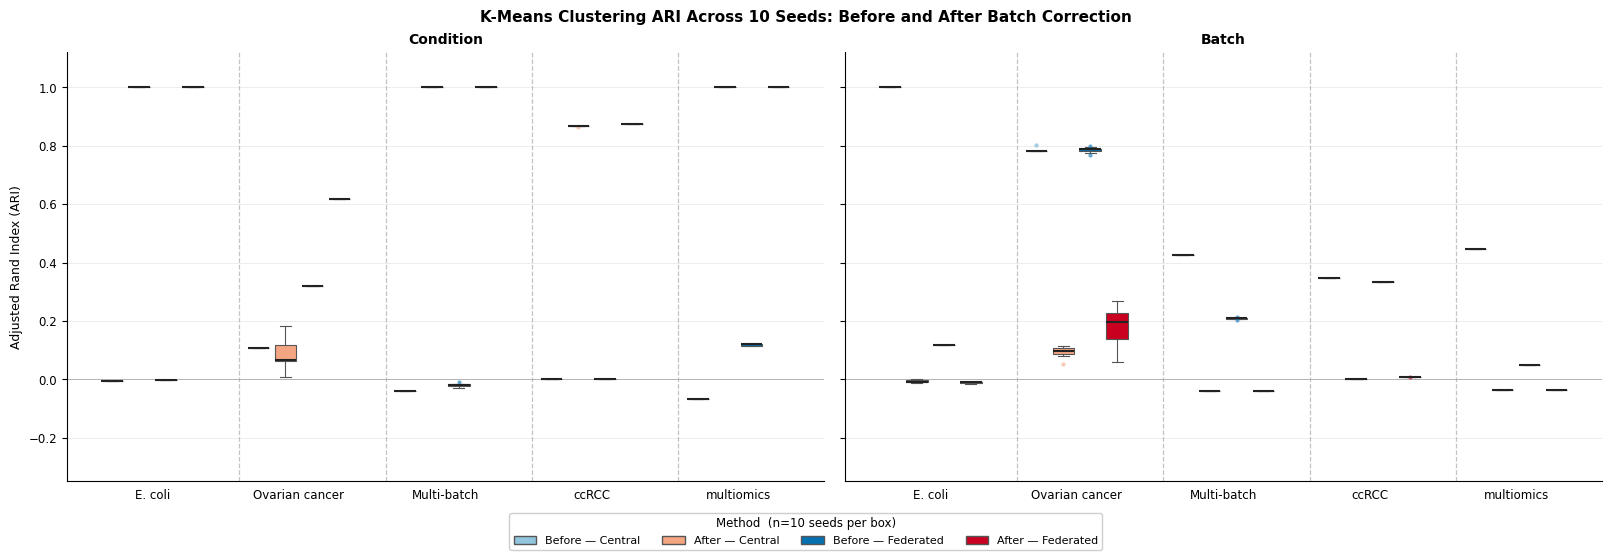

In [15]:
from matplotlib.patches import Patch


def plot_ari_boxplots(results_df, datasets, save_path=None):
    """Publication-quality ARI boxplot: one panel per target, datasets on x-axis."""
    df = results_df.copy()
    present_ds = [d for d in datasets if d in df["Dataset"].values]
    present_methods = [m for m in METHODS_ORDER if m in df["Method"].values]
    n_m = len(present_methods)
    box_w = 0.14
    group_gap = 0.20
    group_w = n_m * box_w + group_gap

    with mpl.rc_context(PUB_RC):
        fig_w = max(7.0, len(present_ds) * group_w * 5 + 2.5)
        fig, axes = plt.subplots(
            1, 2,
            figsize=(min(fig_w, 16), 5.0),
            sharey=True,
            constrained_layout=True,
        )

        for ax_idx, target in enumerate(["condition", "batch"]):
            ax = axes[ax_idx]
            tdf = df[df["Target"] == target]
            xtick_pos, xtick_labels = [], []

            for ds_idx, ds_name in enumerate(present_ds):
                ddf = tdf[tdf["Dataset"] == ds_name]
                x0 = ds_idx * group_w

                for m_idx, method in enumerate(present_methods):
                    mdf = ddf[ddf["Method"] == method]["ARI"].dropna()
                    if mdf.empty:
                        continue
                    xpos = x0 + m_idx * box_w
                    color = METHOD_META[method]["color"]

                    bp = ax.boxplot(
                        mdf.values,
                        positions=[xpos],
                        widths=box_w * 0.80,
                        patch_artist=True,
                        notch=False,
                        showfliers=True,
                        boxprops=dict(facecolor=color, color="#555555", linewidth=0.8),
                        medianprops=dict(color="#222222", linewidth=1.5),
                        whiskerprops=dict(color="#555555", linewidth=0.8),
                        capprops=dict(color="#555555", linewidth=0.8),
                        flierprops=dict(
                            marker="o", markerfacecolor=color,
                            markersize=3, alpha=0.6, markeredgewidth=0,
                        ),
                        zorder=3,
                        manage_ticks=False,
                    )

                center = x0 + (n_m - 1) * box_w / 2
                xtick_pos.append(center)
                xtick_labels.append(DATASET_LABELS.get(ds_name, ds_name))

                if ds_idx < len(present_ds) - 1:
                    ax.axvline(
                        x0 + n_m * box_w + group_gap / 2,
                        color="#aaaaaa", lw=0.9, ls="--", alpha=0.7, zorder=2,
                    )

            ax.axhline(0, color="black", lw=0.6, alpha=0.35, zorder=1)
            ax.set_ylim(-0.35, 1.12)
            ax.set_xticks(xtick_pos)
            ax.set_xticklabels(xtick_labels, fontsize=8.5)
            ax.tick_params(axis="x", length=0, pad=5)
            ax.set_title(TARGET_LABELS[target], fontweight="bold", pad=6)
            if ax_idx == 0:
                ax.set_ylabel("Adjusted Rand Index (ARI)")

        legend_handles = [
            Patch(facecolor=METHOD_META[m]["color"], edgecolor="#555555",
                  label=METHOD_META[m]["label"])
            for m in present_methods
        ]
        fig.legend(
            handles=legend_handles,
            loc="lower center", ncol=len(present_methods),
            bbox_to_anchor=(0.5, -0.10),
            framealpha=0.95, edgecolor="#cccccc",
            title=f"Method  (n={N_RUNS} seeds per box)", title_fontsize=8.5,
        )
        fig.suptitle(
            f"K-Means Clustering ARI Across {N_RUNS} Seeds: Before and After Batch Correction",
            fontweight="bold", fontsize=11,
        )
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
    return fig


fig_box = plot_ari_boxplots(results_df, DATASETS)

**Figure.** Boxplots of ARI across 15 random seeds for each clustering condition.
Each box shows the median (centre line), IQR (box), 1.5×IQR whiskers, and outliers (dots).
Left panel = Condition target; right panel = Batch target.
Colour coding: light blue = Before — Central; orange = After — Central;
dark blue = Before — Federated; dark red = After — Federated.